In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset,TensorDataset,ConcatDataset
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix,classification_report


### 1. Introduction & Data Preparation

The project aims to use probability learning tools in statistics to predict the quality of wine based on its physicochemical indicators

We first imported the red wine and white wine datasets, then extracted the first 500 samples from each and mixed them to form a total dataset containing 1000 samples with 13 features (2 categories and 11 numerics). To transform the regression problem into a binary classification problem, we binarized the target variable quality: a score of 6 or higher was defined as "good wine" (labeled 1), and a score below 6 was defined as "bad wine" (labeled 0).




In [108]:
red_wine = pd.read_csv('wineQuality-red.csv',sep=';')
white_wine = pd.read_csv('wineQuality-white.csv',sep=';')
red_wine=red_wine.iloc[0:500]
red_wine['type'] = "red"
white_wine=white_wine.iloc[0:500]
white_wine['type'] = "white"
total_wine = pd.concat([red_wine,white_wine],ignore_index=True)
total_wine.head()
total_wine['quality'] = (total_wine['quality'] >=6).astype(int)
x = total_wine.drop('quality',axis=1)
y = total_wine['quality']
total_wine.head()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,red


### 2. Define the preprocessing pipeline

The main part of the cell is the function `preprocess_data(x, y, ...)`. This function performs all data preparation needed before training:

- It splits the full dataset into a training portion and a test portion using `train_test_split(..., test_size=0.2, stratify=y)`. Because the full dataset has 1000 rows, this creates 800 training rows and 200 test rows.
- It then splits the 800-row training portion again into a smaller training set and a validation set with `val_size=0.2`. That means the final split is effectively 640 training rows, 160 validation rows, and 200 test rows.
- `stratify=y` is used in both splits so that the class distribution of the binary target stays roughly similar across train, validation, and test data.
- It identifies `type` as the only categorical feature and treats all remaining columns as numeric features.
- It builds a `ColumnTransformer` that standardizes numeric columns with `StandardScaler()` and one-hot encodes the categorical `type` column with `OneHotEncoder()`.
- It fits the preprocessing pipeline on the training data only, then applies the same learned transformation to the validation and test sets. This is important because fitting the scaler on all data would leak test information into the training process.
- Finally, it converts the transformed arrays and labels into PyTorch tensors, wraps them inside `TensorDataset`, and creates `DataLoader` objects for mini-batch training.



In [109]:
seed = 666
np.random.seed(seed)
torch.manual_seed(seed)

def preprocess_data(x,y,test_size=0.2,val_size=0.2,batch_size=80,seed=seed):
    x_full_train,x_test,y_full_train,y_test = train_test_split(
        x,y,test_size=test_size,stratify=y,random_state=seed
    )
    x_train,x_val,y_train,y_val = train_test_split(
        x_full_train,y_full_train,test_size=val_size,random_state=seed,stratify=y_full_train
    )
    category_cols = ['type']
    numeric_cols = [col for col in x.columns if col not in category_cols]
    processor = ColumnTransformer([
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(), category_cols)
    ])
    x_train = processor.fit_transform(x_train)
    x_val = processor.transform(x_val)
    x_test = processor.transform(x_test)

    train_td = TensorDataset(
        torch.tensor(x_train,dtype=torch.float32),
        torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
    )
    val_td = TensorDataset(
        torch.tensor(x_val,dtype=torch.float32),
        torch.tensor(y_val.values,dtype=torch.float32).view(-1,1)
    )
    test_td = TensorDataset(
        torch.tensor(x_test,dtype=torch.float32),
        torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)
    )

    train_loader = DataLoader(train_td,batch_size=batch_size,shuffle=True)
    val_loader = DataLoader(val_td,batch_size=batch_size,shuffle=False)
    test_loader = DataLoader(test_td,batch_size=batch_size,shuffle=False)

    return train_loader, val_loader, test_loader,processor,x_full_train,y_full_train
    

### 3. Define the neural network model

Defines the class `WineQualityClassifier`, which inherits from `nn.Module`. The model is a feedforward multilayer perceptron with the following structure:

- an input layer of size 13,
- a first hidden layer with `hidden1` units,
- a ReLU activation,
- dropout for regularization,
- a second hidden layer with `hidden2` units,
- another ReLU activation and dropout,
- a final output layer with one unit.

The `forward()` method simply passes the input tensor through this sequence of layers.


In [110]:
class WineQualityClassifier(nn.Module):
    def __init__(self, input_dim=13,hidden1=64,hidden2=32,dropout=0.2,num_classes=1,batch_size=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),  
            nn.ReLU(),                 
            nn.Dropout(dropout),           
            nn.Linear(hidden1, hidden2),         
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes)            
        )
    
    def forward(self, x):
        return self.net(x)


### 4. Define the training, evaluation, and prediction helpers

Creates four helper functions that control the full learning process.

`train_one_epoch(...)`:
- sets the model to training mode with `model.train()`,
- loops over mini-batches from the training loader,
- computes predictions (`logits`),
- evaluates the loss,
- performs backpropagation with `loss.backward()`,
- updates the parameters with `optimizer.step()`,
- accumulates average loss and accuracy across the epoch.

`evaluate(...)`:
- switches to evaluation mode with `model.eval()`,
- disables gradients with `torch.no_grad()`,
- computes loss and accuracy on validation or test data without changing the model weights.

`fit_model(...)`:
- repeatedly calls the training and evaluation functions for multiple epochs,
- stores the training and validation loss/accuracy in the `history` dictionary,
- prints a progress line after each epoch.

`predict_all(...)`:
- collects all true labels and predicted labels from a loader,
- applies `torch.sigmoid(logits)` to convert logits into probabilities,
- thresholds those probabilities at `0.5`,
- returns NumPy arrays for later use in a confusion matrix and classification report.


In [111]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        probs = torch.sigmoid(logits)        
        preds = (probs > 0.5).float() 
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            correct += (preds == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total


def fit_model(model, train_loader, val_loader, criterion, optimizer, epochs):

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )
    return history

def predict_all(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).long()
            y_pred.extend(preds.numpy().tolist())
            y_true.extend(y.numpy().tolist())
    return np.array(y_true), np.array(y_pred)


### 5. Define plotting functions for diagnostics


In [112]:
def plot_learning_curves(history, title_prefix="Model"):

    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="Train")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} loss curves")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="Train")
    plt.plot(epochs, history["val_acc"], marker="o", label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} accuracy curves")
    plt.legend()
    plt.tight_layout()
    plt.show()



def plot_confusion_with_offdiag_highlight(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred).astype(float)
    n = cm.shape[0]
    diag_mask = np.eye(n, dtype=bool)
    off_diag_mask = ~diag_mask
    diag_vals = np.where(diag_mask, cm, np.nan)
    off_diag_vals = np.where(off_diag_mask, cm, np.nan)
    fig, ax = plt.subplots(figsize=(8, 6))
    off_diag_max = np.nanmax(off_diag_vals) if np.any(off_diag_mask) else 0.0
    if np.isfinite(off_diag_max) and off_diag_max > 0:
        sns.heatmap(
            off_diag_vals,
            mask=np.isnan(off_diag_vals),
            cmap=sns.light_palette("#d62728", as_cmap=True),
            vmin=0,
            vmax=off_diag_max,
            cbar=False,
            ax=ax,
            linewidths=0.3,
            linecolor="white",
        )
    diag_max = np.nanmax(diag_vals) if np.any(diag_mask) else 0.0
    if np.isfinite(diag_max) and diag_max > 0:
        sns.heatmap(
            diag_vals,
            mask=np.isnan(diag_vals),
            cmap=sns.light_palette("#1f77b4", as_cmap=True),
            vmin=0,
            vmax=diag_max,
            cbar=False,
            ax=ax,
            linewidths=0.3,
            linecolor="white",
        )
    for i in range(n):
        for j in range(n):
            ax.text(j + 0.5, i + 0.5, f"{int(cm[i, j])}", ha="center", va="center", color="black", fontsize=9)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(n) + 0.5)
    ax.set_yticks(np.arange(n) + 0.5)
    ax.set_xticklabels(range(n))
    ax.set_yticklabels(range(n), rotation=0)
    ax.text(
        0.0,
        -0.12,
        "Blue scale: diagonal (correct) | Red scale: off-diagonal (errors)",
        transform=ax.transAxes,
        fontsize=9,
        color="dimgray",
    )
    plt.tight_layout()
    plt.show()

### 6. Train the baseline neural network

Set up the first complete experiment, which acts as the **baseline model**.

A baseline is necessary because tuning only makes sense if there is something to compare against. This first run answers the question: *How well does a straightforward neural network perform before any hyperparameter search?*

**output：**

The printed lines report four values per epoch，from the output, the learning trend is clearly positive:
- training loss drops from about `0.6836` to `0.5780`,
- validation loss drops from about `0.6701` to `0.5226`,
- validation accuracy rises from about `0.7125` to `0.7812`.

This means the model is learning real signal from the input features rather than behaving like random guessing. The validation performance improves steadily instead of collapsing, so there is no strong sign of severe overfitting within these 20 epochs.


In [113]:
baseline_cfg = {
    "hidden1": 64,
    "hidden2": 32,
    "dropout": 0.2,
    "lr": 1e-3,
    "epochs": 20,
    "batch_size": 80,
}

train_loader, val_loader, test_loader, processor, x_full_train, y_full_train = preprocess_data(
    x,y,batch_size=baseline_cfg["batch_size"] 
)

baseline_model = WineQualityClassifier(
    hidden1=baseline_cfg["hidden1"],
    hidden2=baseline_cfg["hidden2"],
    dropout=baseline_cfg["dropout"],
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=baseline_cfg["lr"])

baseline_history = fit_model(
    baseline_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=baseline_cfg["epochs"],
)


Epoch 01/20 | train_loss=0.6836, train_acc=0.5844 | val_loss=0.6701, val_acc=0.7125
Epoch 02/20 | train_loss=0.6684, train_acc=0.6375 | val_loss=0.6528, val_acc=0.7562
Epoch 03/20 | train_loss=0.6531, train_acc=0.6656 | val_loss=0.6341, val_acc=0.7063
Epoch 04/20 | train_loss=0.6401, train_acc=0.6391 | val_loss=0.6160, val_acc=0.7312
Epoch 05/20 | train_loss=0.6308, train_acc=0.6422 | val_loss=0.5992, val_acc=0.7562
Epoch 06/20 | train_loss=0.6208, train_acc=0.6516 | val_loss=0.5842, val_acc=0.7250
Epoch 07/20 | train_loss=0.6095, train_acc=0.6781 | val_loss=0.5715, val_acc=0.7250
Epoch 08/20 | train_loss=0.6057, train_acc=0.6781 | val_loss=0.5621, val_acc=0.7375
Epoch 09/20 | train_loss=0.6008, train_acc=0.6797 | val_loss=0.5563, val_acc=0.7438
Epoch 10/20 | train_loss=0.6000, train_acc=0.6937 | val_loss=0.5517, val_acc=0.7438
Epoch 11/20 | train_loss=0.5891, train_acc=0.6828 | val_loss=0.5487, val_acc=0.7312
Epoch 12/20 | train_loss=0.5915, train_acc=0.6828 | val_loss=0.5433, val_acc

### 7. Visualize the baseline learning curves


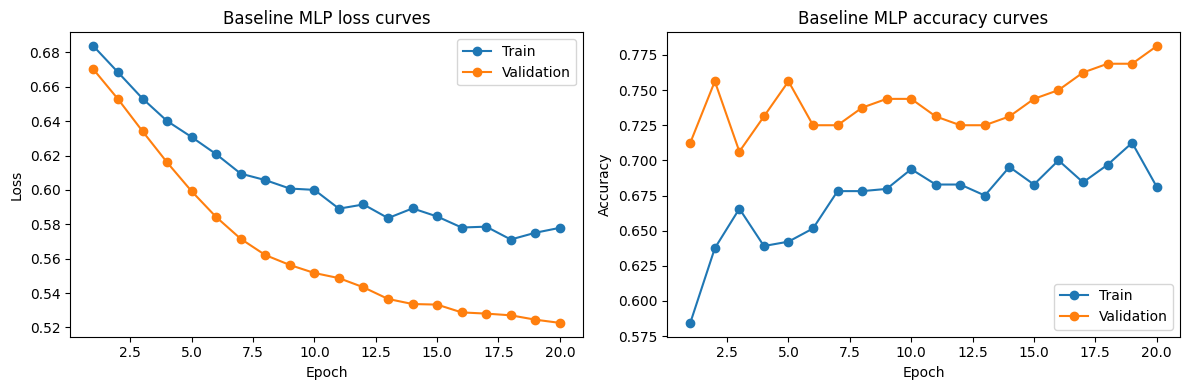

In [114]:
plot_learning_curves(baseline_history, title_prefix="Baseline MLP")

### 8. Evaluate the baseline model on the test set

The printed values show:
- `Baseline test loss: 0.5594`
- `Baseline test accuracy: 0.7250`

Looking at the classification report:
- Class `0.0` has precision `0.6634` and recall `0.7614`. This means the model catches many of the lower-quality wines, although some predicted low-quality wines are actually high-quality.
- Class `1.0` has precision `0.7879` and recall `0.6964`. This means when the model predicts a higher-quality wine, it is usually correct, but it still misses a noticeable portion of truly higher-quality wines.
- The weighted F1-score is `0.7260`, which indicates a moderate but meaningful baseline performance.


Baseline test loss: 0.5594
Baseline test accuracy: 0.7250


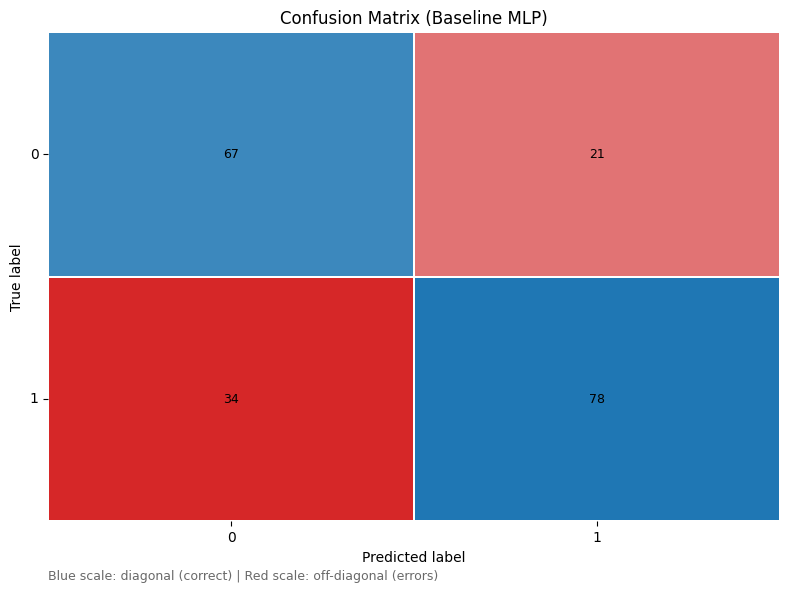

              precision    recall  f1-score   support

         0.0     0.6634    0.7614    0.7090        88
         1.0     0.7879    0.6964    0.7393       112

    accuracy                         0.7250       200
   macro avg     0.7256    0.7289    0.7242       200
weighted avg     0.7331    0.7250    0.7260       200



In [115]:
test_loss, test_acc = evaluate(baseline_model, test_loader, criterion)
print(f"Baseline test loss: {test_loss:.4f}")
print(f"Baseline test accuracy: {test_acc:.4f}")
y_true, y_pred = predict_all(baseline_model, test_loader)
plot_confusion_with_offdiag_highlight(
    y_true,
    y_pred,
    title="Confusion Matrix (Baseline MLP)",
)
print(classification_report(y_true, y_pred, digits=4))

### 9. Define the function used for one hyperparameter experiment

Defines `run_experiment(cfg, epochs)`. Given a dictionary of hyperparameters, it adds `weight_decay=1e-4`, which introduces L2-style regularization.


In [116]:
def run_experiment(cfg, epochs):
    model = WineQualityClassifier(
        hidden1=cfg["hidden1"],
        hidden2=cfg["hidden2"],
        dropout=cfg["dropout"],
        batch_size=cfg["batch_size"]
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"],weight_decay=1e-4)

    train_loader_new, val_loader_new, _, _, _, _ = preprocess_data(
        x, y,
        batch_size=cfg["batch_size"]
    )
    history = fit_model(
        model,
        train_loader_new,
        val_loader_new,
        criterion,
        optimizer,
        epochs=epochs      
    )

    best_val_acc = max(history["val_acc"])

    return {
        "config": cfg,
        "best_val_acc": best_val_acc
    }

### 10. Run the hyperparameter grid search and rank the candidate models

Defines four candidate hyperparameter settings and then loops over them and saves the best configuration in `best_cfg`.

**output:**

The best parameters are:
- ` val_acc = 0.7875  ` for `(128, 64)` with `dropout = 0.2` and `lr = 0.001`, `batch_size = 32`



In [117]:
grid = [
    {"hidden1": 64,  "hidden2": 32,  "dropout": 0.2, "lr": 1e-3, "batch_size": 32},
    {"hidden1": 128, "hidden2": 64,  "dropout": 0.2, "lr": 1e-3, "batch_size": 32},
    {"hidden1": 128, "hidden2": 64,  "dropout": 0.3, "lr": 3e-4, "batch_size": 64},
    {"hidden1": 256, "hidden2": 128, "dropout": 0.3, "lr": 3e-4, "batch_size": 64},
]

results = []
for i, cfg in enumerate(grid):
    result = run_experiment(cfg, epochs=20)
    results.append(result)

results = sorted(results, key=lambda x: x["best_val_acc"], reverse=True)

print("\nRanked tuning results:")
for rank, r in enumerate(results, start=1):
    cfg = r["config"]
    print(
        f"{rank}. val_acc={r['best_val_acc']:.4f} | "
        f"hidden=({cfg['hidden1']},{cfg['hidden2']}), "
        f"lr={cfg['lr']}, dropout={cfg['dropout']}"
    )

best_cfg = results[0]["config"]
print(f"\nBest config selected: {best_cfg}")


Epoch 01/20 | train_loss=0.6807, train_acc=0.5766 | val_loss=0.6650, val_acc=0.6312
Epoch 02/20 | train_loss=0.6608, train_acc=0.6219 | val_loss=0.6397, val_acc=0.6500
Epoch 03/20 | train_loss=0.6372, train_acc=0.6375 | val_loss=0.6161, val_acc=0.7125
Epoch 04/20 | train_loss=0.6178, train_acc=0.6734 | val_loss=0.5905, val_acc=0.7250
Epoch 05/20 | train_loss=0.5992, train_acc=0.6703 | val_loss=0.5714, val_acc=0.7250
Epoch 06/20 | train_loss=0.5958, train_acc=0.6828 | val_loss=0.5591, val_acc=0.7125
Epoch 07/20 | train_loss=0.5924, train_acc=0.6953 | val_loss=0.5546, val_acc=0.7312
Epoch 08/20 | train_loss=0.5795, train_acc=0.6906 | val_loss=0.5486, val_acc=0.7188
Epoch 09/20 | train_loss=0.5863, train_acc=0.7094 | val_loss=0.5497, val_acc=0.7312
Epoch 10/20 | train_loss=0.5726, train_acc=0.7188 | val_loss=0.5377, val_acc=0.7438
Epoch 11/20 | train_loss=0.5720, train_acc=0.7203 | val_loss=0.5331, val_acc=0.7438
Epoch 12/20 | train_loss=0.5661, train_acc=0.7078 | val_loss=0.5351, val_acc

### 11. Retrain the final model with the selected hyperparameters and evaluate it

- refit the preprocessing pipeline on `x_full_train`,
- transform the full training data,
- build a `TensorDataset` and `DataLoader` for all available training examples,
- create the final model with `best_cfg`,
- use `BCEWithLogitsLoss()` and Adam with weight decay,
- train for 80 epochs,
- evaluate on the test set,

**output**

- `Best-config test loss: 0.5399`
- `Best-config test accuracy: 0.7800`
- `Baseline test accuracy: 0.7250`
- Class `0.0` has recall `0.8068`, which means the tuned model identifies lower-quality wines more successfully than before.
- Class `1.0` has precision `0.8333`, which means predictions of higher-quality wines are usually reliable.
- The weighted F1-score is `0.7808`, which is better than the baseline report and indicates an overall improvement in classification quality.


Epoch 01/80 | train_loss=0.6666, train_acc=0.6175 | val_loss=0.6351, val_acc=0.6550
Epoch 02/80 | train_loss=0.6132, train_acc=0.6613 | val_loss=0.5882, val_acc=0.6837
Epoch 03/80 | train_loss=0.5860, train_acc=0.6800 | val_loss=0.5681, val_acc=0.6963
Epoch 04/80 | train_loss=0.5757, train_acc=0.6937 | val_loss=0.5576, val_acc=0.7025
Epoch 05/80 | train_loss=0.5628, train_acc=0.7075 | val_loss=0.5502, val_acc=0.7013
Epoch 06/80 | train_loss=0.5557, train_acc=0.7188 | val_loss=0.5417, val_acc=0.7200
Epoch 07/80 | train_loss=0.5498, train_acc=0.7150 | val_loss=0.5342, val_acc=0.7238
Epoch 08/80 | train_loss=0.5470, train_acc=0.7225 | val_loss=0.5273, val_acc=0.7350
Epoch 09/80 | train_loss=0.5437, train_acc=0.7312 | val_loss=0.5225, val_acc=0.7400
Epoch 10/80 | train_loss=0.5354, train_acc=0.7300 | val_loss=0.5207, val_acc=0.7412
Epoch 11/80 | train_loss=0.5306, train_acc=0.7338 | val_loss=0.5118, val_acc=0.7550
Epoch 12/80 | train_loss=0.5214, train_acc=0.7338 | val_loss=0.5062, val_acc

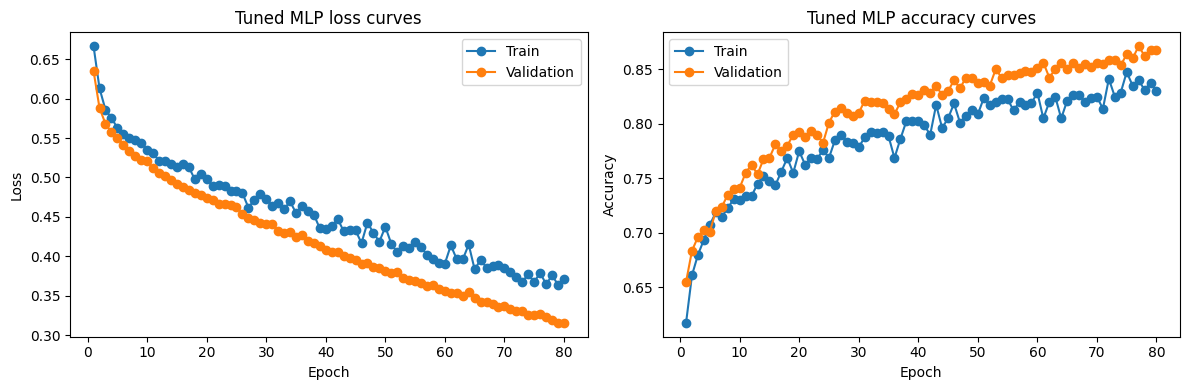

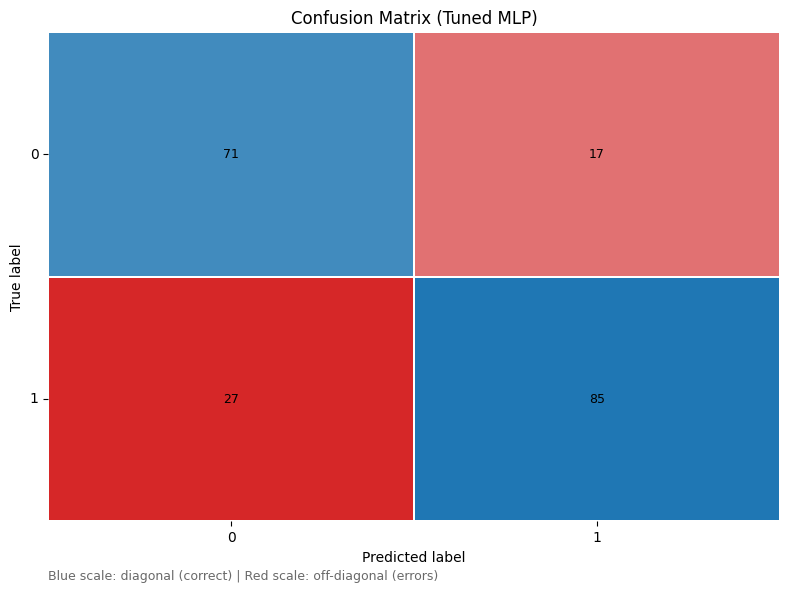

              precision    recall  f1-score   support

         0.0     0.7245    0.8068    0.7634        88
         1.0     0.8333    0.7589    0.7944       112

    accuracy                         0.7800       200
   macro avg     0.7789    0.7829    0.7789       200
weighted avg     0.7854    0.7800    0.7808       200



In [118]:
x_full_train_scaled = processor.fit_transform(x_full_train)
full_train_dataset = TensorDataset(
    torch.tensor(x_full_train_scaled,dtype=torch.float32),
    torch.tensor(y_full_train.values,dtype=torch.float32).view(-1,1)
)
full_train_loader = DataLoader(full_train_dataset,batch_size=best_cfg["batch_size"],shuffle=True)

best_model = WineQualityClassifier(
    hidden1=best_cfg["hidden1"],
    hidden2=best_cfg["hidden2"],
    dropout=best_cfg["dropout"]
)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    best_model.parameters(),
    lr=best_cfg["lr"],
    weight_decay=1e-4
)
best_history = fit_model(
    best_model,
    full_train_loader,
    full_train_loader,
    criterion,
    optimizer,
    epochs=80
)

best_test_loss, best_test_acc = evaluate(best_model, test_loader, criterion)
print(f"Best-config test loss: {best_test_loss:.4f}")
print(f"Best-config test accuracy: {best_test_acc:.4f}")
print(f"Baseline test accuracy: {test_acc:.4f}")

plot_learning_curves(best_history, title_prefix="Tuned MLP")
best_y_true, best_y_pred = predict_all(best_model, test_loader)
plot_confusion_with_offdiag_highlight(
    best_y_true,
    best_y_pred,
    title="Confusion Matrix (Tuned MLP)",
)

print(classification_report(best_y_true, best_y_pred, digits=4))

